# Stage 2 — multi-pair labeling (config-driven)

This notebook re-runs the Stage 1 labeling pipeline across the top USDT pairs using YAML configs. It keeps the heavy lifting configurable while giving quick visuals around the global alpha/beta derived from pooled 1-candle returns.


## Notebook goals
- Load labeling + path settings from YAML instead of hard-coding anything
- Discover the top USDT pairs and download their OHLCV history (cached by `HistoryLoader`)
- Estimate global alpha/beta from pooled 1-bar returns and visualise the distribution
- Run the Stage 1 pipeline for each pair with those thresholds and store artifacts under `stage1/stage2_data`
- Spot-check one of the generated datasets for sanity


In [8]:
# %pip install pandas numpy pyyaml matplotlib seaborn tqdm pyarrow


In [9]:
from __future__ import annotations

import fnmatch
import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from tqdm.notebook import tqdm

from history_loader import HistoryLoader
from pipeline_stage1 import Stage1Config, Stage1Paths, Stage1Pipeline

sns.set_theme(style="whitegrid")
HAS_PLOTS = True


In [10]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "configs").exists() else NOTEBOOK_DIR.parent

LABEL_CFG_PATH = PROJECT_ROOT / "configs" / "labeling_stage2.yaml"
PATH_CFG_PATH = PROJECT_ROOT / "configs" / "paths_stage2.yaml"


def load_yaml(path: Path) -> Dict[str, Any]:
    if not path.exists():
        raise FileNotFoundError(f"Missing config: {path}")
    with path.open("r", encoding="utf-8") as handle:
        payload = yaml.safe_load(handle) or {}
    if not isinstance(payload, dict):
        raise ValueError(f"Expected mapping in {path}, got {type(payload).__name__}")
    return payload


label_cfg = load_yaml(LABEL_CFG_PATH)
paths_cfg = load_yaml(PATH_CFG_PATH)

symbol_pattern = str(label_cfg.get("symbol", "*USDT"))
interval = str(label_cfg["interval"])
fee = float(label_cfg["fee"])
backW_values = [int(v) for v in label_cfg.get("backW", [])]
forW_values = [int(v) for v in label_cfg.get("forW", [])]
top_n_pairs = int(label_cfg.get("top_n_pairs", 20))
start_date = label_cfg.get("start_date", "1 Jan 2020")
end_date = label_cfg.get("end_date")
single_pct = label_cfg.get("single_candle_percentiles", {"alpha_pct": 0.15, "beta_pct": 0.997})
scale_beta_per_step = float(label_cfg.get("scale_beta_per_step", 0.10))

paths = Stage1Paths(
    processed_dir=(PROJECT_ROOT / paths_cfg["processed_dir"]).expanduser().resolve(),
    datasets_dir=(PROJECT_ROOT / paths_cfg["datasets_dir"]).expanduser().resolve(),
    reports_dir=(PROJECT_ROOT / paths_cfg["reports_dir"]).expanduser().resolve(),
)
paths.ensure()

print(f"Project root: {PROJECT_ROOT}")
print(f"Labeling config: {LABEL_CFG_PATH.name}")
print(f"Paths config:    {PATH_CFG_PATH.name}")
print(f"Interval: {interval} | backW={backW_values} | forW={forW_values} | fee={fee}")
print(f"Symbol pattern: {symbol_pattern} | top_n_pairs={top_n_pairs}")


Project root: /home/kamil/binance-bot
Labeling config: labeling_stage2.yaml
Paths config:    paths_stage2.yaml
Interval: 4h | backW=[1, 2, 3, 4, 5] | forW=[1, 2, 3, 4, 5] | fee=0.001
Symbol pattern: *USDT | top_n_pairs=600


## Discover the pairs
We grab tradable symbols that match the pattern from `labeling_stage2.yaml` (default `*USDT`) and rank them by 24h quote volume when available. If the 24h ticker endpoint is unavailable, we fall back to alphabetical order.


Selected 437 symbols: BTCUSDT, ETHUSDT, USDCUSDT, SOLUSDT, BNBUSDT, FDUSDUSDT, XRPUSDT, ZECUSDT, DOGEUSDT, ASTERUSDT, SUIUSDT, TRXUSDT, ADAUSDT, AVAXUSDT, UNIUSDT, LINKUSDT, PEPEUSDT, BCHUSDT, ENAUSDT, HMSTRUSDT, XPLUSDT, PAXGUSDT, LTCUSDT, NEARUSDT, USDEUSDT, EURUSDT, LAYERUSDT, TAOUSDT, AAVEUSDT, USD1USDT, 0GUSDT, PUMPUSDT, PENGUUSDT, WIFUSDT, GIGGLEUSDT, ARBUSDT, BARDUSDT, DOTUSDT, FILUSDT, LUNAUSDT, WLDUSDT, APTUSDT, HBARUSDT, ACTUSDT, SHIBUSDT, BONKUSDT, SEIUSDT, WBTCUSDT, BFUSDUSDT, TRUMPUSDT, POLUSDT, USTCUSDT, TONUSDT, LUNCUSDT, CAKEUSDT, ICPUSDT, WLFIUSDT, VIRTUALUSDT, STRKUSDT, XUSDUSDT, XLMUSDT, FETUSDT, OPUSDT, CRVUSDT, INJUSDT, ATUSDT, EIGENUSDT, FORMUSDT, MMTUSDT, SYRUPUSDT, USUALUSDT, OGUSDT, SOMIUSDT, TIAUSDT, AIXBTUSDT, LRCUSDT, ATOMUSDT, DASHUSDT, ETCUSDT, FLOKIUSDT, LDOUSDT, NEIROUSDT, PENDLEUSDT, ARUSDT, HAEDALUSDT, ZENUSDT, ONDOUSDT, ETHFIUSDT, ORDIUSDT, ARKMUSDT, HEMIUSDT, BERAUSDT, 1INCHUSDT, LINEAUSDT, JUVUSDT, GALAUSDT, RENDERUSDT, DOGSUSDT, ZKUSDT, EPICUSDT, T

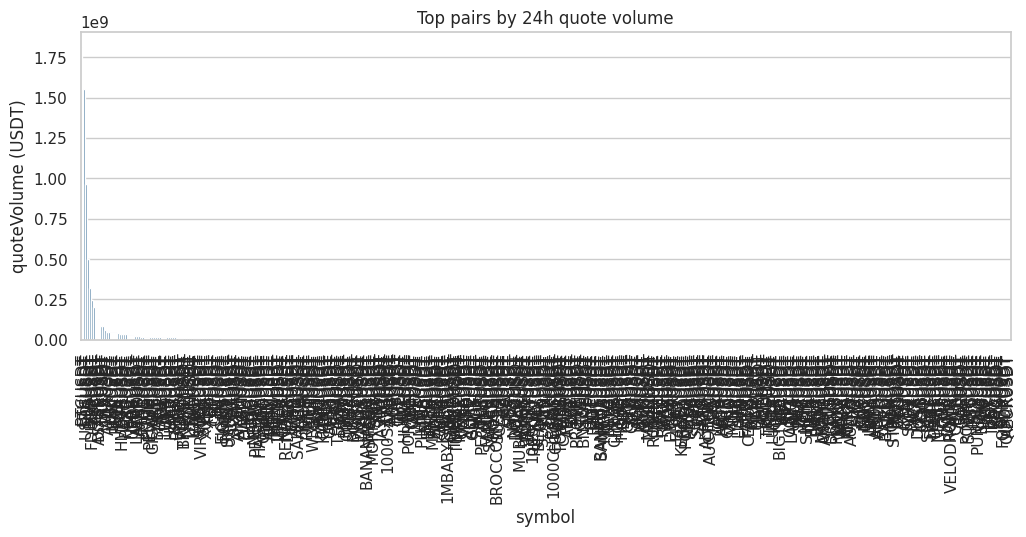

In [11]:
loader = HistoryLoader()


def pick_symbols(pattern: str, top_n: int) -> Tuple[pd.DataFrame, List[str]]:
    info = loader.client.exchange_info()
    symbols_df = pd.DataFrame(info["symbols"])
    symbols_df = symbols_df[symbols_df["status"] == "TRADING"]

    if pattern.startswith("*") and pattern.endswith("USDT"):
        quote = pattern.replace("*", "")
        mask = symbols_df["quoteAsset"].str.upper() == quote.upper()
    else:
        mask = symbols_df["symbol"].apply(lambda s: fnmatch.fnmatch(s, pattern))
    candidates = symbols_df[mask].copy()

    try:
        ticker_df = pd.DataFrame(loader.client.ticker_24hr())
        ticker_df["quoteVolume"] = ticker_df["quoteVolume"].astype(float)
        candidates = candidates.merge(ticker_df[["symbol", "quoteVolume"]], on="symbol", how="left")
        candidates = candidates.sort_values("quoteVolume", ascending=False)
    except Exception as exc:  # noqa: BLE001
        print(f"Falling back to alphabetical order (24h ticker unavailable): {exc}")
        candidates["quoteVolume"] = np.nan
        candidates = candidates.sort_values("symbol")

    selected = candidates.head(top_n).copy()
    symbols = selected["symbol"].tolist()
    if not symbols:
        raise RuntimeError(f"No symbols matched pattern {pattern}")
    return selected, symbols


symbols_meta, symbols = pick_symbols(symbol_pattern, top_n_pairs)
print(f"Selected {len(symbols)} symbols: {', '.join(symbols)}")

if HAS_PLOTS and "quoteVolume" in symbols_meta:
    fig, ax = plt.subplots(figsize=(12, 4))
    sns.barplot(data=symbols_meta, x="symbol", y="quoteVolume", ax=ax, color="steelblue")
    ax.set_title("Top pairs by 24h quote volume")
    ax.set_ylabel("quoteVolume (USDT)")
    ax.tick_params(axis='x', rotation=90)
    plt.show()


## Download OHLCV & pool 1-candle returns
All data goes through `HistoryLoader`, which caches to disk to avoid repeated API calls. We pool 1-bar absolute returns across pairs to derive the global alpha/beta percentiles declared in the YAML config.


  0%|          | 0/437 [00:00<?, ?it/s]

ASTERUSDT: returned empty dataframe
XPLUSDT: returned empty dataframe
USDEUSDT: returned empty dataframe
LAYERUSDT: returned empty dataframe
USD1USDT: returned empty dataframe
0GUSDT: returned empty dataframe
PUMPUSDT: returned empty dataframe
GIGGLEUSDT: returned empty dataframe
BARDUSDT: returned empty dataframe
BFUSDUSDT: returned empty dataframe
TRUMPUSDT: returned empty dataframe
WLFIUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
VIRTUALUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
XUSDUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
ATUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
FORMUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
MMTUSDT: failed to download -> Invalid comparison between dtype=datetime64[ns] and Timestamp
SYRUPUSDT: failed to download -> Invalid compari

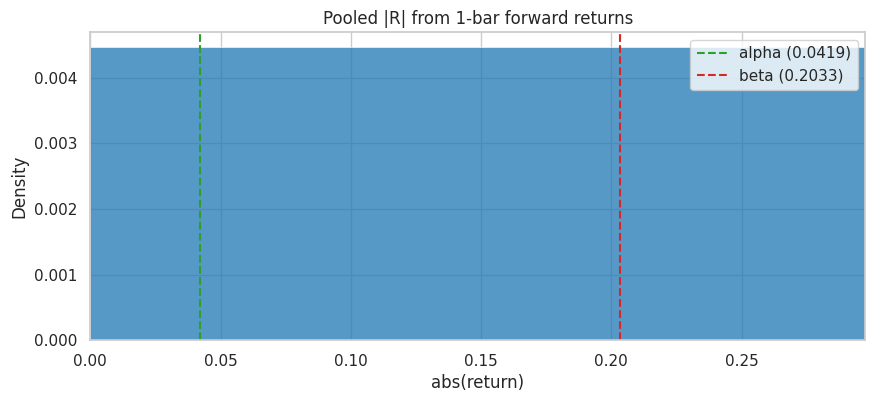

In [12]:
data_store: Dict[str, pd.DataFrame] = {}
print(f"Downloading {len(symbols)} pairs for interval {interval} starting {start_date}...")

for symbol in tqdm(symbols):
    try:
        df = loader.load(symbol, interval=interval, start_time=start_date, end_time=end_date)
    except Exception as exc:  # noqa: BLE001
        print(f"{symbol}: failed to download -> {exc}")
        continue
    if df.empty:
        print(f"{symbol}: returned empty dataframe")
        continue
    data_store[symbol] = df

if not data_store:
    raise RuntimeError("No data downloaded; cannot proceed with labeling.")

all_returns = []
for symbol, df in data_store.items():
    close_fwd = df["close"].shift(-1)
    r1 = ((1.0 - fee) * close_fwd - (1.0 + fee) * df["open"]) / df["open"]
    all_returns.append(r1.abs().dropna())

global_returns = pd.concat(all_returns)
alpha = float(global_returns.quantile(single_pct["alpha_pct"]))
beta = float(global_returns.quantile(single_pct["beta_pct"]))

print(f"Global sample size: {len(global_returns):,}  | alpha={alpha:.6f}  | beta={beta:.6f}")

if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(global_returns, bins=120, stat="density", color="tab:blue", ax=ax,)
    ax.axvline(alpha, color="tab:green", linestyle="--", label=f"alpha ({alpha:.4f})")
    ax.axvline(beta, color="tab:red", linestyle="--", label=f"beta ({beta:.4f})",)
    ax.set_title("Pooled |R| from 1-bar forward returns")
    ax.set_xlabel("abs(return)")
    ax.set_xlim(0, global_returns.quantile(0.999))
    ax.legend()
    plt.show()


## Run Stage 1 labeling per pair
We reuse the Stage 1 pipeline but feed in the global alpha/beta constants computed above. All artifacts land under the folders declared in `configs/paths_stage2.yaml`.


In [13]:
qa_records: List[Dict[str, Any]] = []

for symbol in tqdm(symbols):
    cfg = Stage1Config(
        symbol=symbol,
        interval=interval,
        fee=fee,
        backW_values=backW_values,
        forW_values=forW_values,
        percentiles_by_forW={},
        paths=paths,
        calibration_mode="exact_paper",
        alpha_const=alpha,
        beta_const=beta,
        single_candle_percentiles=single_pct,
        scale_beta_per_step=scale_beta_per_step,
        start_date=start_date,
    )

    pipeline = Stage1Pipeline(cfg, history_loader=loader)
    try:
        qa = pipeline.run()
        qa_records.append({"symbol": symbol, "status": qa.status, "gaps_pct": qa.gaps_pct, "notes": qa.notes})
    except Exception as exc:  # noqa: BLE001
        qa_records.append({"symbol": symbol, "status": "FAIL", "gaps_pct": np.nan, "notes": str(exc)})

qa_df = pd.DataFrame(qa_records)
qa_df


  0%|          | 0/437 [00:00<?, ?it/s]

,symbol,status,gaps_pct,notes
0,BTCUSDT,OK,0.007649,First gap starts at 2020-02-19T16:00:00+00:00
1,ETHUSDT,OK,0.007649,First gap starts at 2020-02-19T16:00:00+00:00
2,USDCUSDT,WARN,7.641704,First gap starts at 2020-02-19T16:00:00+00:00
3,SOLUSDT,OK,0.000000,
4,BNBUSDT,OK,0.007649,First gap starts at 2020-02-19T16:00:00+00:00
...,...,...,...,...
432,UTKUSDT,OK,0.000000,
433,FORTHUSDT,OK,0.000000,
434,USDPUSDT,FAIL,NaN,QA failed: QAReport(gaps_pct=10.65783853054250...
435,QUICKUSDT,OK,0.262329,First gap starts at 2023-07-21T08:00:00+00:00


In [15]:
qa_df ['status'].value_counts()

status
OK      432
WARN      3
FAIL      2
Name: count, dtype: int64

In [18]:
qa_df[qa_df ['status'] != 'FAIL']['symbol'].to_csv('labeled_symbols.csv', index=True)

So we have 435 pairs with USDT that will do